# Cookie Cats A/B Test — Should the Gate Move from Level 30 to Level 40?

**Product:** Cookie Cats — a mobile puzzle game (Tactile Entertainment).

**Context:** the game has "gates" — points where the player must wait or pay to continue. The gate originally sat at level 30. The product team proposed moving it to level 40, hypothesizing that a longer free path would keep more players engaged.

**Product question:** does moving the gate affect player retention?

**Hypotheses:**

- H0: moving the gate has no effect on retention
- H1: moving the gate affects retention

**Success metrics:** Retention D1 (did the player return the next day) and Retention D7 (did the player return after a week) — standard mobile-gaming retention metrics that reflect the quality of the early player experience.

## 1. Load and inspect the data

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('cookie_cats.csv')
print(df.shape)

(90189, 5)


In [3]:
display(df.head(), df.tail())

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


,userid,version,sum_gamerounds,retention_1,retention_7
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False
90188,9999861,gate_40,16,False,False


The dataset contains **90 189** players and **5** columns
- `userid`
- `version` (which test group the player was assigned to)
- `sum_gamerounds` (rounds played in the first 14 days)
- `retention_1`
- `retention_7` (did the player return on day 1 / day 7).

No missing values — the data is clean and ready to analyze.

## 2. Check group sizes

First step: confirm the randomization worked — the groups should be roughly equal in size. 
A large imbalance would be a red flag about how the data was collected.

In [4]:
df['version'].value_counts()

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

Groups are balanced (**44 700** vs **45 489**) — randomization looks correct, so the test results can be trusted.

## 3. Retention by group

Calculate the share of players who returned on day 1 and day 7, separately for each version.

In [6]:
summary = df.groupby('version').agg(    n=('userid','count'),    ret1_rate=('retention_1','mean'),    ret7_rate=('retention_7','mean'),    median_rounds=('sum_gamerounds','median'))
summary

,n,ret1_rate,ret7_rate,median_rounds
version,,,,
gate_30,44700,0.448188,0.190201,17.0
gate_40,45489,0.442283,0.182000,16.0


**What's already visible at this step:** 

retention is lower in the `gate_40` group on both metrics:
- Retention D1: 44.2% vs 44.8% (a −0.6 pp difference, or −1.3% in relative terms)
- Retention D7: 18.2% vs 19.0% (a −0.8 pp difference, or **−4.3%** in relative terms)

The gap is small, and it's not obvious by eye whether it's random noise — that's what the significance test is for.

## 4. Statistical significance: chi-square test

Both metrics are binary (returned / did not return), so this is a classic two-proportion comparison. We build a contingency table (returned vs not, by group) and test whether the game version is associated with retention using a chi-square test (the categorical-data analog of a t-test).

In [8]:
ct1 = pd.crosstab(df['version'], df['retention_1'])
chi2_1, p1, dof1, exp1 = stats.chi2_contingency(ct1, correction=False)

print(ct1)
print(f"chi2 = {chi2_1:.4f}, p-value = {p1:.4f}")

retention_1  False  True 
version                  
gate_30      24666  20034
gate_40      25370  20119
chi2 = 3.1830, p-value = 0.0744


In [9]:
ct7 = pd.crosstab(df['version'], df['retention_7'])
chi2_7, p7, dof7, exp7 = stats.chi2_contingency(ct7, correction=False)

print(ct7)
print(f"chi2 = {chi2_7:.4f}, p-value = {p7:.4f}")

retention_7  False  True 
version                  
gate_30      36198   8502
gate_40      37210   8279
chi2 = 10.0132, p-value = 0.0016


**Interpreting the p-value** (using the standard 0.05 threshold):

- Retention D1: p = 0.074 → **above 0.05**, no significant difference proven (could be random noise)
- Retention D7: p = 0.0016 → **below 0.05**, the difference is statistically significant — not noise

So the short-term effect (D1) is not proven, while over a week (D7) moving the gate **significantly reduces** retention.

## 5. Cross-check with a second method — two-proportion z-test (manual)

For clarity, I re-derive the same significance test using the two-proportion z-test formula.

In [10]:
def two_prop_ztest(x1, n1, x2, n2):
    p1, p2 = x1/n1, x2/n2    
    p_pool = (x1 + x2) / (n1 + n2)    
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))    
    z = (p1 - p2) / se
    
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))    
    
    return z, p_value
    
g30 = df[df.version == 'gate_30']
g40 = df[df.version == 'gate_40']

z7, pz7 = two_prop_ztest(g30.retention_7.sum(), len(g30), g40.retention_7.sum(), len(g40))

print(f"retention_7: z = {z7:.4f}, p = {pz7:.4f}")

retention_7: z = 3.1644, p = 0.0016


Matches the chi-square result — as expected, and a good sanity check that the calculation is correct.

## 6. Visualization

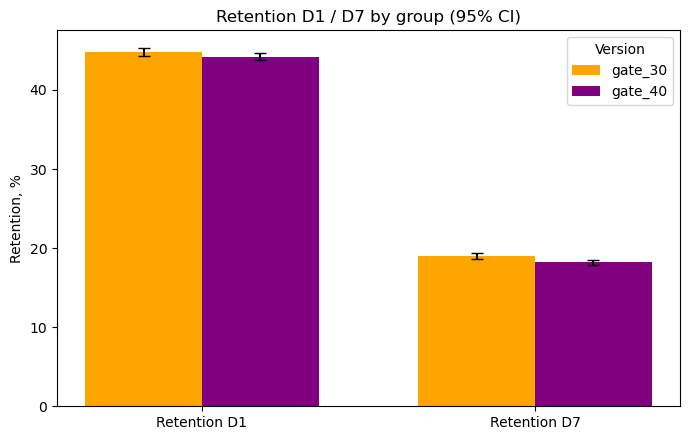

In [42]:
def prop_ci(x, n, z=1.96):
    p = x / n
    se = np.sqrt(p * (1 - p) / n)
    return p, z * se


fig, ax = plt.subplots(figsize=(7, 4.5))

groups = ['gate_30', 'gate_40']
metrics = ['retention_1', 'retention_7']
labels = ['Retention D1', 'Retention D7']

x = np.arange(len(metrics))
width = 0.35
colors = ['orange', 'purple']

for i, g in enumerate(groups):
    gdf = df[df.version == g]
    vals, errs = [], []

    for m in metrics:
        p, err = prop_ci(gdf[m].sum(), len(gdf))
        vals.append(p * 100)
        errs.append(err * 100)

    ax.bar(x + (i - 0.5) * width, vals, width,
           yerr=errs, capsize=4, label=g, color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Retention, %')
ax.set_title('Retention D1 / D7 by group (95% CI)')
ax.legend(title='Version')

plt.tight_layout()
plt.show()

The 95% confidence intervals for D1 overlap — visually confirming the difference there is inconclusive. For D7 the intervals barely overlap, consistent with the significant p-value.

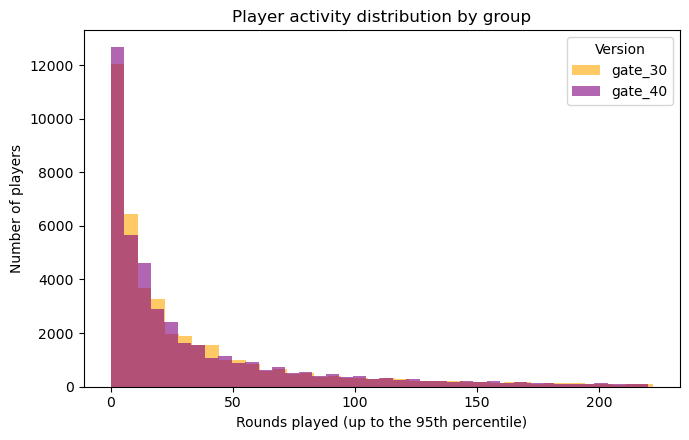

In [46]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for g, c in zip(['gate_30', 'gate_40'], ['orange', 'purple']):
    vals = df[df.version == g]['sum_gamerounds']
    vals = vals[vals <= vals.quantile(0.95)]  # trim outliers for readability
    ax.hist(vals, bins=40, alpha=0.6, label=g, color=c)

ax.set_xlabel('Rounds played (up to the 95th percentile)')
ax.set_ylabel('Number of players')
ax.set_title('Player activity distribution by group')
ax.legend(title='Version')

plt.tight_layout()
plt.show()

## 7. Conclusion and recommendation**

Moving the gate from level 30 to level 40 significantly reduces Retention D7 by 4.3% in relative terms** (p = 0.0016), while the effect on Retention D1 is not statistically proven (p = 0.074).

**Recommendation to the product team:** 

do not move the gate to level 40 — the change offers no upside and risks losing weekly retention at this sample size. The earlier gate (level 30) appears to function as a gentler monetization/pause point that doesn't push players away in the moment, without hurting long-term engagement.